# Lesson 1.5 — Finite Difference Method

## The Slope Approximation

You already know calculus tells us the derivative is the limit of a slope:

$$\frac{du}{dx} = \lim_{\Delta x \to 0} \frac{u(x + \Delta x) - u(x)}{\Delta x}$$

The Finite Difference Method (FDM) simply **stops before taking the limit**. On a grid
with spacing $\Delta x$, we approximate derivatives with differences between neighbouring
grid values. The art is choosing *which* neighbours and understanding what error you incur.

---

## Taylor Series — The Foundation

All finite difference formulas come from the Taylor series. Expanding $u_{i+1} = u(x_i + \Delta x)$:

$$u_{i+1} = u_i + \Delta x \, u'_i + \frac{\Delta x^2}{2} u''_i + \frac{\Delta x^3}{6} u'''_i + \cdots$$

Rearranging: $u'_i = \frac{u_{i+1} - u_i}{\Delta x} - \frac{\Delta x}{2} u''_i - \cdots$

Dropping the $O(\Delta x)$ tail gives the **forward difference**:

$$u'_i \approx \frac{u_{i+1} - u_i}{\Delta x} + O(\Delta x)$$

## The Three Standard Stencils

| Name | Formula | Order | Uses |
|------|---------|-------|------|
| Forward difference | $\frac{u_{i+1} - u_i}{\Delta x}$ | $O(\Delta x)$ | Advection (upwind) |
| Backward difference | $\frac{u_i - u_{i-1}}{\Delta x}$ | $O(\Delta x)$ | Advection (upwind) |
| Central difference | $\frac{u_{i+1} - u_{i-1}}{2\Delta x}$ | $O(\Delta x^2)$ | Diffusion, pressure gradients |

The **central difference** is second-order — halving the grid spacing reduces the error by 4×.
The forward/backward are first-order — halving the spacing only halves the error.

---

## Second Derivative

Adding the Taylor expansions for $u_{i+1}$ and $u_{i-1}$:

$$u_{i+1} + u_{i-1} = 2u_i + \Delta x^2 u''_i + O(\Delta x^4)$$

$$\Rightarrow \quad u''_i \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2} + O(\Delta x^2)$$

This second-derivative stencil appears in every diffusion equation and Poisson equation in CFD.
Memorise it: **`u[i+1] - 2*u[i] + u[i-1]`**.

---

## Truncation Error and Order of Accuracy

The **truncation error** is what you drop when you truncate the Taylor series.
For the central difference: $\tau = \frac{\Delta x^2}{6} u''' + O(\Delta x^4)$.

The scheme is "second-order" because the leading error term is $\propto \Delta x^2$.
Refining the grid by 2× reduces the error by $2^2 = 4\times$.


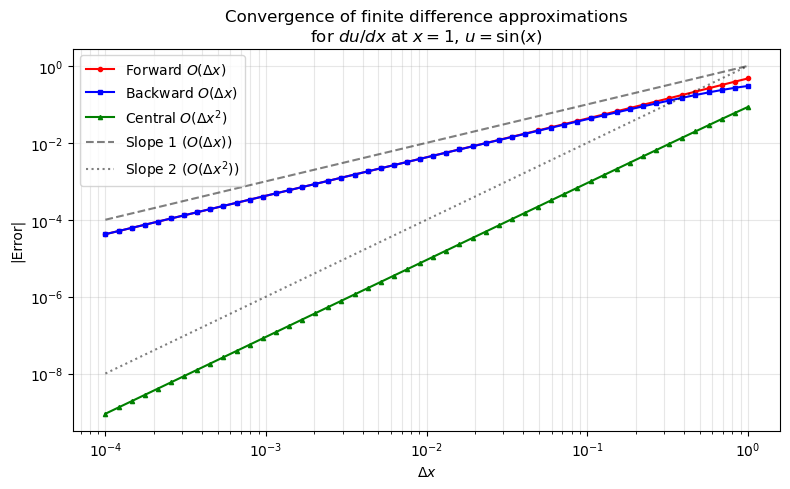

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Compare forward, backward, central differences for du/dx of u = sin(x)
# Exact: du/dx = cos(x)

dx_values = np.logspace(-4, 0, 50)
x0 = 1.0  # evaluate at this point
u_exact_deriv = np.cos(x0)

err_fwd = []
err_bwd = []
err_cen = []

for dx in dx_values:
    u_plus  = np.sin(x0 + dx)
    u_minus = np.sin(x0 - dx)
    u_0     = np.sin(x0)
    
    fwd = (u_plus - u_0) / dx
    bwd = (u_0 - u_minus) / dx
    cen = (u_plus - u_minus) / (2*dx)
    
    err_fwd.append(abs(fwd - u_exact_deriv))
    err_bwd.append(abs(bwd - u_exact_deriv))
    err_cen.append(abs(cen - u_exact_deriv))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(dx_values, err_fwd, 'r-o', markersize=3, label='Forward $O(\\Delta x)$')
ax.loglog(dx_values, err_bwd, 'b-s', markersize=3, label='Backward $O(\\Delta x)$')
ax.loglog(dx_values, err_cen, 'g-^', markersize=3, label='Central $O(\\Delta x^2)$')

# Reference slopes
ax.loglog(dx_values, dx_values, 'k--', alpha=0.5, label='Slope 1 ($O(\\Delta x)$)')
ax.loglog(dx_values, dx_values**2, 'k:', alpha=0.5, label='Slope 2 ($O(\\Delta x^2)$)')

ax.set_xlabel('$\\Delta x$')
ax.set_ylabel('|Error|')
ax.set_title('Convergence of finite difference approximations\nfor $du/dx$ at $x=1$, $u=\\sin(x)$')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Max error in 2D Laplacian: 4.7217e-04  (dx=dy=0.0532)
Expected O(dx²) error: 2.8353e-03


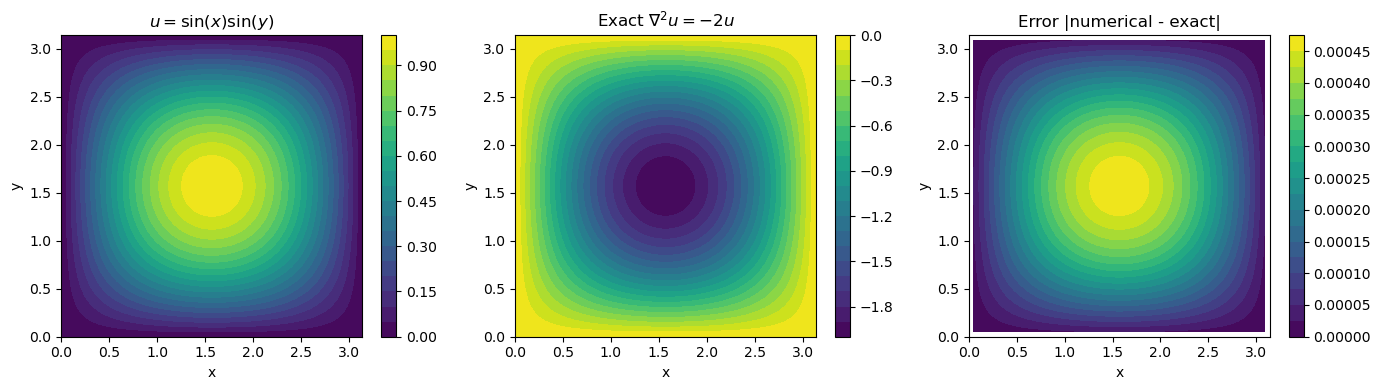

In [2]:
# 2D Laplacian using central differences
# Verify: for u = sin(x)*sin(y), the exact Laplacian is -2*sin(x)*sin(y) = -2u

N = 60
x = np.linspace(0, np.pi, N)
y = np.linspace(0, np.pi, N)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)

u = np.sin(X) * np.sin(Y)
exact_laplacian = -2 * u

# Numerical Laplacian: d²u/dx² + d²u/dy²
lap = np.zeros_like(u)
lap[1:-1, 1:-1] = (
    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2 +
    (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2
)

error = np.abs(lap[1:-1, 1:-1] - exact_laplacian[1:-1, 1:-1])
print(f"Max error in 2D Laplacian: {error.max():.4e}  (dx=dy={dx:.4f})")
print(f"Expected O(dx²) error: {dx**2:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['$u = \\sin(x)\\sin(y)$', 'Exact $\\nabla^2 u = -2u$', 'Error |numerical - exact|']
fields = [u, exact_laplacian, np.where(
    np.array([[i>0 and i<N-1 and j>0 and j<N-1 for j in range(N)] for i in range(N)]),
    np.abs(lap - exact_laplacian), np.nan)]

for ax, field, title in zip(axes, fields, titles):
    cf = ax.contourf(X, Y, field, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## Boundary Conditions in FDM

At the domain boundary, one-sided stencils are used (since there's no neighbour on one side):

- **Dirichlet BC** (prescribed value): $u_0 = u_{\text{wall}}$ — just set the boundary value directly.
- **Neumann BC** (prescribed gradient): $du/dx|_0 = g$ — use a ghost cell: $u_{-1} = u_1 - 2 \Delta x \, g$.

Ghost cells are fictitious values outside the domain. They allow interior stencils to be applied
uniformly at boundaries without special-casing the code.

## Key Takeaways

- All FD formulas come from truncating the Taylor series.
- Central differences: $O(\Delta x^2)$ accuracy. Forward/backward: $O(\Delta x)$ accuracy.
- The second-derivative stencil $u_{i+1} - 2u_i + u_{i-1}$ is used in every diffusion equation.
- Order of accuracy tells you how fast the error decreases with grid refinement.
- Ghost cells enforce Neumann BCs without modifying the interior stencil.

---

**Next**: Lesson 1.6 — 1D Linear Advection: your first PDE solver.
